## Недообучение и переобучение 

### Классная работа

In [372]:
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_classification, fetch_openml
from sklearn.model_selection import train_test_split, LearningCurveDisplay, learning_curve, validation_curve
from sklearn.linear_model import RidgeClassifier, LogisticRegression, Lasso, ElasticNet
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from yellowbrick.model_selection import LearningCurve

import warnings
warnings.filterwarnings('ignore')

#### Классификация

In [16]:
X, y = make_classification(n_samples=10000, n_features=500,
                           n_informative=50, n_repeated=0,
                           class_sep=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=3)

In [18]:
lr = LogisticRegression().fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8413
Test score: 0.8056


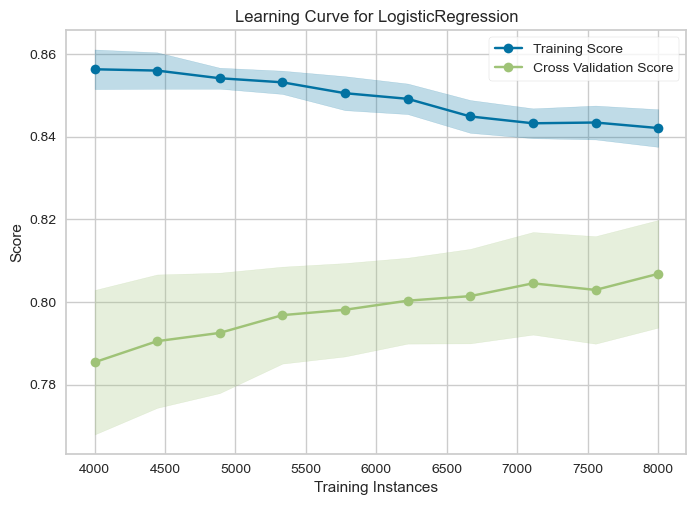

In [20]:
visualizer = LearningCurve(
    LogisticRegression(), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

In [22]:
lr = RidgeClassifier(alpha=1000000).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.7724
Test score: 0.7712


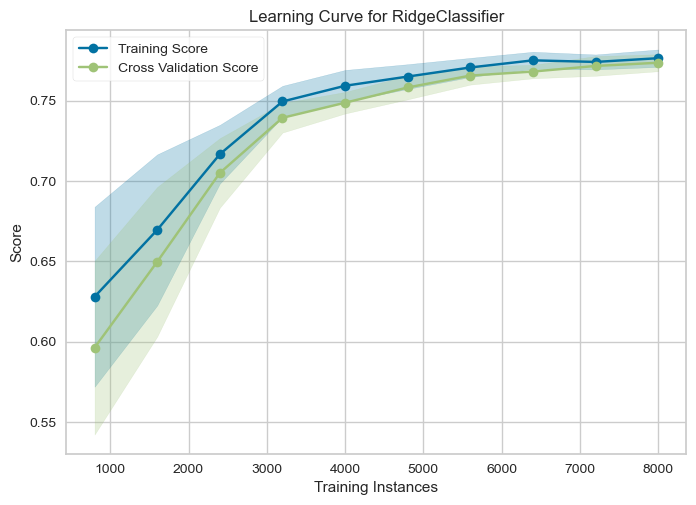

In [24]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=1000000), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

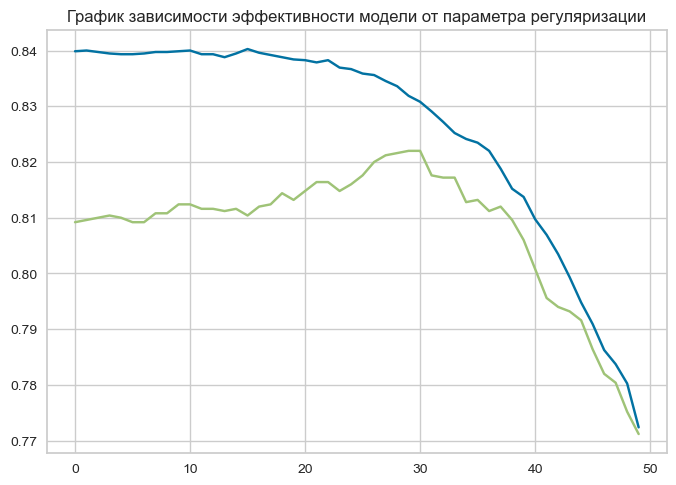

In [25]:
trains = []
tests = []
plt.title('График зависимости эффективности модели от параметра регуляризации')
for i in np.logspace(2, 6, 50):
  ridge = RidgeClassifier(alpha=i).fit(X_train, y_train)
  trains.append(ridge.score(X_train, y_train))
  tests.append(ridge.score(X_test, y_test))

plt.plot(trains)
plt.plot(tests)

In [28]:
lr = RidgeClassifier(alpha=26500).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8311
Test score: 0.8228


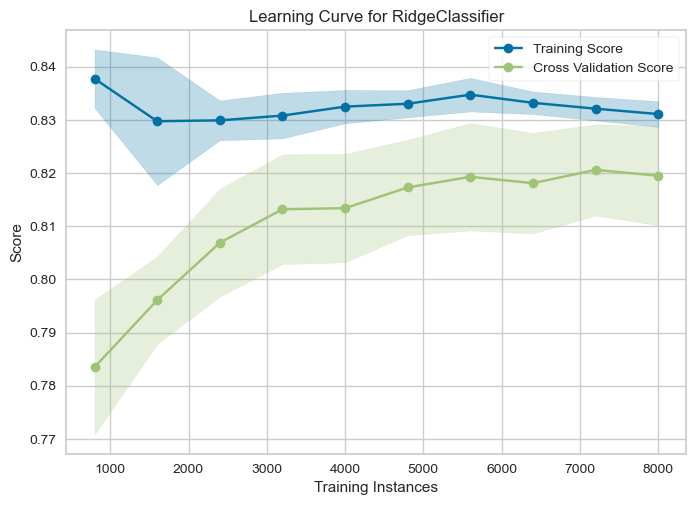

In [30]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=26500), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

#### Регрессия

In [33]:
from numpy import genfromtxt
dataset = genfromtxt('https://raw.githubusercontent.com/datatweets/tutorials/refs/heads/main/misc/boston_housing.csv', delimiter=',')
X = dataset[:,:-1]
y = dataset[:,-1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

In [35]:
lr = LinearRegression().fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.9521
Test score: 0.6075


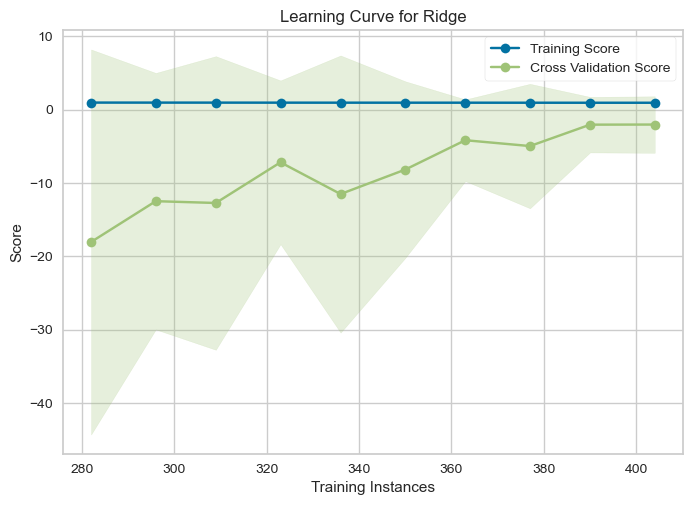

In [37]:
from yellowbrick.model_selection import LearningCurve
visualizer = LearningCurve(
    Ridge(alpha=0.0001), scoring='r2', train_sizes=np.linspace(0.7, 1.0, 10)
).fit(X, y) .show()

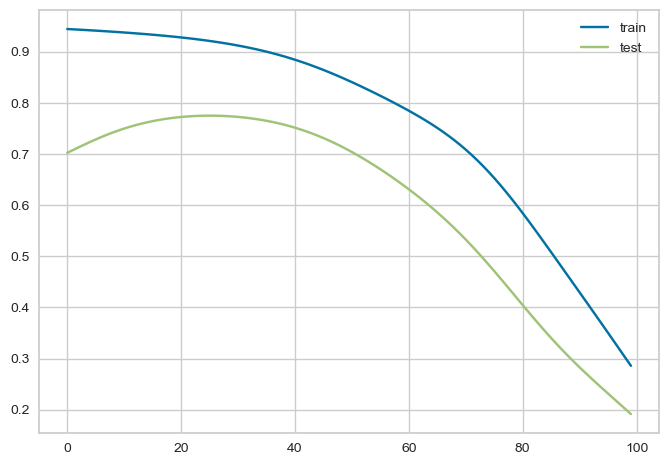

In [39]:
from sklearn.linear_model import Ridge
trains = []
tests = []
for i in np.logspace(-2, 3, 100):
  # Initialize and train a new Ridge regressor for each alpha value
  ridge_regressor = Ridge(alpha=i).fit(X_train, y_train)
  trains.append(ridge_regressor.score(X_train, y_train))
  tests.append(ridge_regressor.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

In [41]:
lr = Ridge(alpha=0.18).fit(X_train, y_train)

print(f"Linear Regression-Training set score: {lr.score(X_train, y_train):.2f}")
print(f"Linear Regression-Test set score: {lr.score(X_test, y_test):.2f}")

Linear Regression-Training set score: 0.92
Linear Regression-Test set score: 0.77


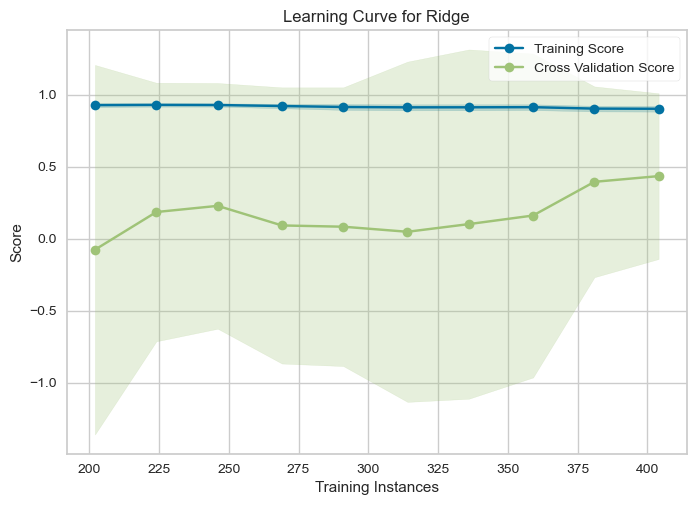

In [43]:
visualizer = LearningCurve(
    Ridge(alpha=0.18), scoring='r2', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show()

C:\Users\Home\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.440e+02, tolerance: 3.233e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.449e+02, tolerance: 3.233e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.459e+02, tolerance: 

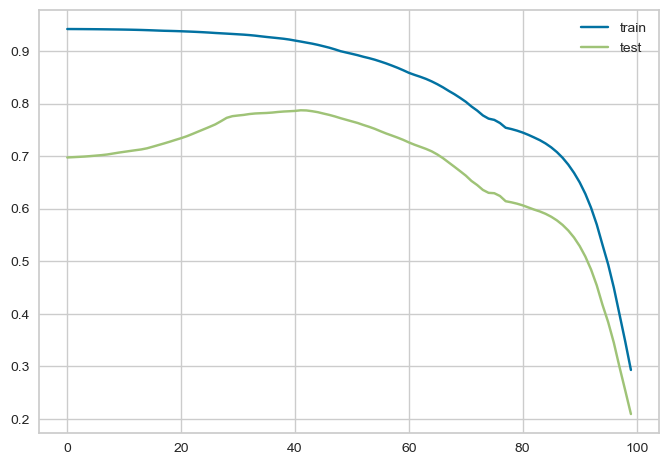

In [45]:
from sklearn.linear_model import Lasso
trains = []
tests = []
for i in np.logspace(-4, 0, 100):
  ridge = Lasso(alpha=i).fit(X_train, y_train)
  trains.append(ridge.score(X_train, y_train))
  tests.append(ridge.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

#### Диагностика на реальных данных

In [48]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv',nrows=200)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [50]:
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 1.0000
Test score = 0.5500


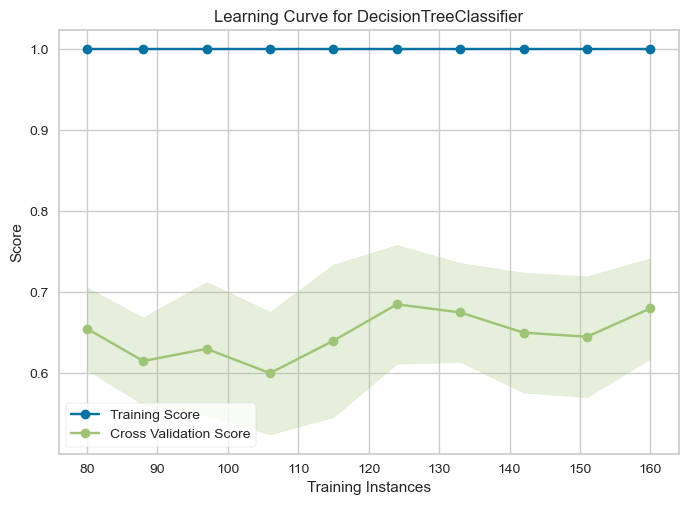

In [54]:
visualizer = LearningCurve(
    DecisionTreeClassifier(random_state=1), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show()

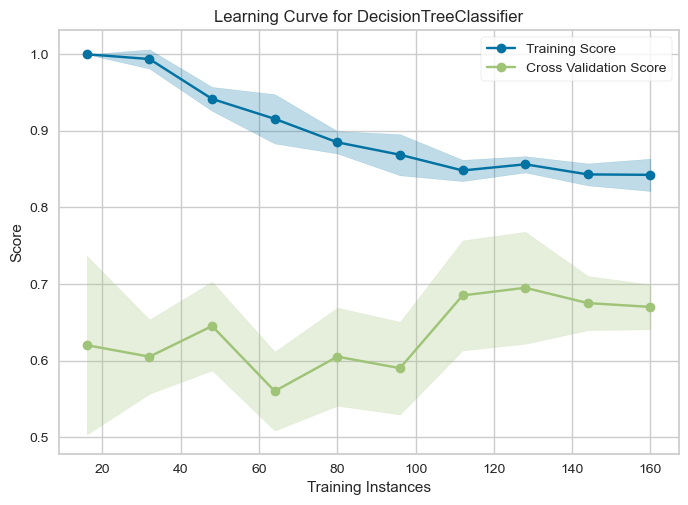

In [56]:
visualizer = LearningCurve(
    DecisionTreeClassifier(max_depth=4), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

In [58]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv')
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
from sklearn.metrics import f1_score
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 1.0000
Test score = 0.7273


#### Диагностика недообучения

In [61]:
from sklearn.datasets import fetch_openml
data = fetch_openml(name='delta_ailerons', parser="auto")
data.data.shape

(7129, 5)

In [62]:
X = pd.get_dummies(data.data)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [65]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.6092
Test score = 0.5989


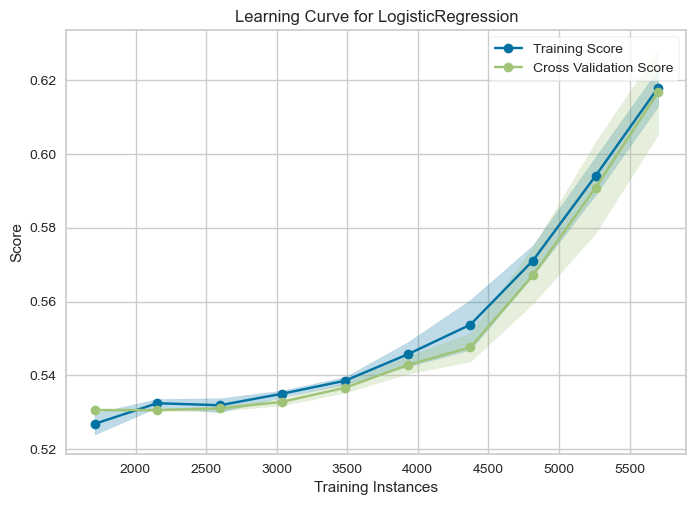

In [67]:
visualizer = LearningCurve(
    LogisticRegression(), scoring='accuracy', train_sizes=np.linspace(0.3, 1.0, 10)
).fit(X, y) .show()

При недообучении регуляризация не поможет, даже навредит, так как еще усилит его. Поэтому единственный путь в этом случае - использовать более сложные, вариативные модели.

In [70]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier().fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9386
Test score = 0.9404


C:\Users\Home\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\Users\Home\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Home\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer

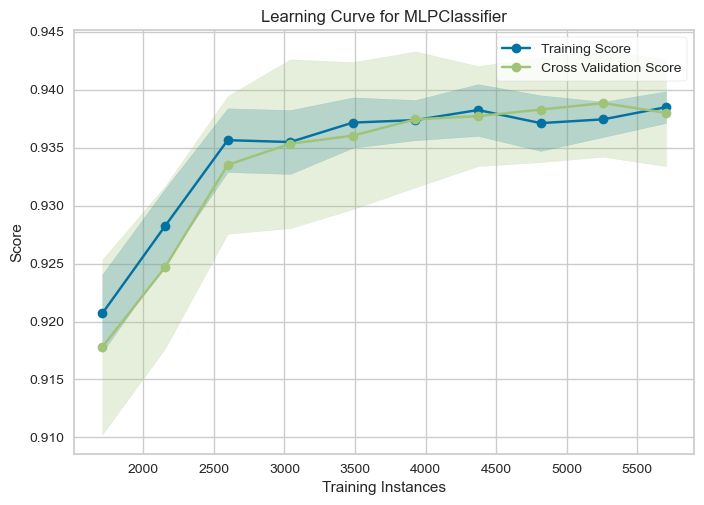

In [72]:
visualizer = LearningCurve(
    MLPClassifier(), scoring='accuracy', train_sizes=np.linspace(0.3, 1.0, 10)
).fit(X, y) .show()

In [73]:
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import PolynomialFeatures
model = RidgeClassifier(alpha=0.001).fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
y_train_pred = model.predict(PolynomialFeatures(2).fit_transform(X_train))
y_pred = model.predict(PolynomialFeatures(2).fit_transform(X_test))
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9392
Test score = 0.9362


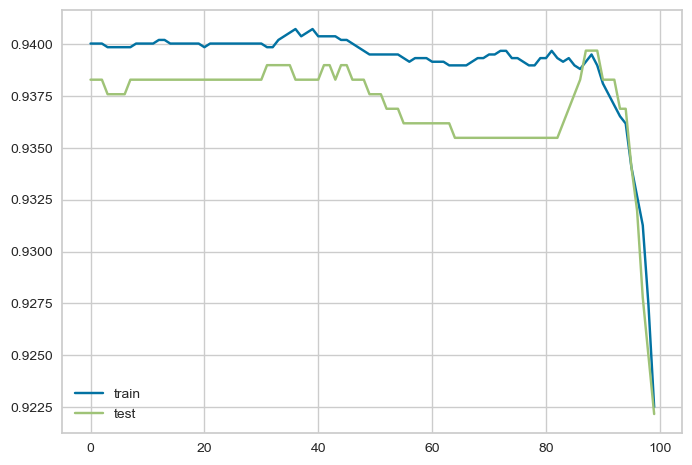

In [74]:
from sklearn.linear_model import RidgeClassifier
trains = []
tests = []
for i in np.logspace(-7, 0, 100):
  ridge = RidgeClassifier(alpha=i).fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
  trains.append(ridge.score(PolynomialFeatures(2).fit_transform(X_train), y_train))
  tests.append(ridge.score(PolynomialFeatures(2).fit_transform(X_test), y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

### Задания для самостоятельного выполнения

#### 1. Повторите диагностику модели классификации синтетических данных с использованием других метрик эффективности - precision, recall, F1. Как изменились результаты?

In [100]:
X, y = make_classification(n_samples=10000, n_features=500,
                           n_informative=50, n_repeated=0,
                           class_sep=1, random_state=42)

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=3)

In [104]:
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)

In [106]:
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

In [114]:
train_precision = precision_score(y_train, y_train_pred)
test_precision = precision_score(y_test, y_test_pred)

print(f"Training precision: {train_precision:.4f}")
print(f"Test precision: {test_precision:.4f}")

Training precision: 0.8337
Test precision: 0.8069


In [116]:
train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

print(f"Training recall: {train_recall:.4f}")
print(f"Test recall: {test_recall:.4f}")

Training recall: 0.8515
Test recall: 0.8056


In [118]:
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Training F1: {train_f1:.4f}")
print(f"Test F1: {test_f1:.4f}")

Training F1: 0.8425
Test F1: 0.8062


#### 2. Повторите диагностику модели регрессии с использованием других видов моделей:
- метода опорных векторов (исследуйте влияние параметра С на недо-и переобучение)
- метода ближайших соседей (исследуйте влияние количества соседей)
- метода решающих деревьев (гиперпараметры по вашему выбору)

In [135]:
dataset = fetch_openml(data_id=531, as_frame=True, parser='auto')
#dataset = genfromtxt('https://raw.githubusercontent.com/datatweets/tutorials/refs/heads/main/misc/boston_housing.csv', delimiter=',')

In [131]:
X = dataset.data.values.astype(float)
y = dataset.target.values.astype(float)

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

##### SVR (метод опорных векторов)

In [137]:
C_range = np.logspace(-1, 3, 50)
train_scores, test_scores = [], []

In [198]:
for C in C_range:
    model = make_pipeline(StandardScaler(), SVR(C=C, kernel='rbf'))
    model.fit(X_train, y_train)
    
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

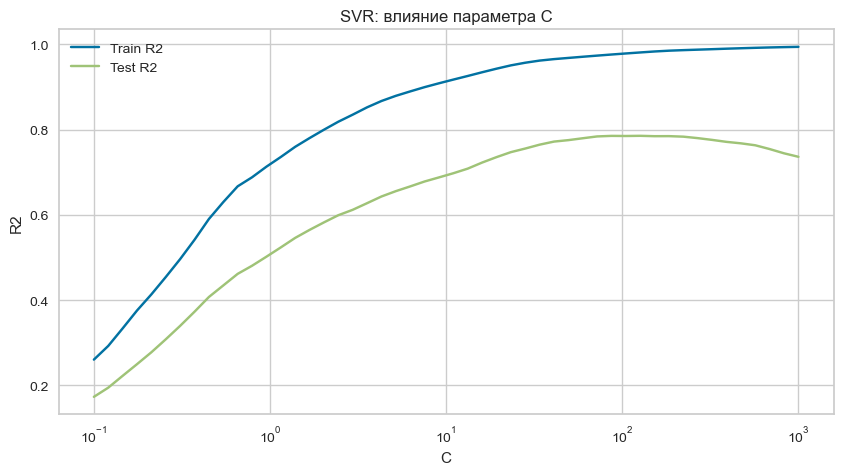

In [141]:
plt.figure(figsize=(10, 5))
plt.semilogx(C_range, train_scores, label='Train R2')
plt.semilogx(C_range, test_scores, label='Test R2')
plt.xlabel('C')
plt.ylabel('R2')
plt.title('SVR: влияние параметра C')
plt.legend()
plt.grid(True)
plt.show()

Кривая обучения для оптимального C

In [146]:
train_sizes, train_scores, test_scores = learning_curve(
    make_pipeline(StandardScaler(), SVR(C=100)), X, y,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='r2', n_jobs=-1)

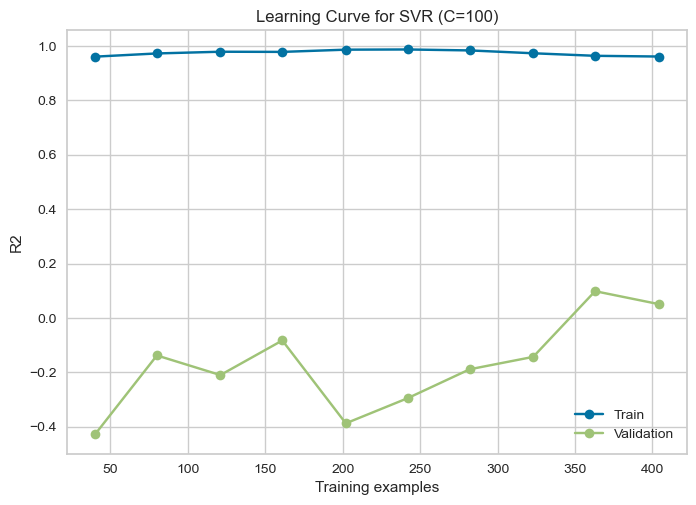

In [148]:
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Train')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label='Validation')
plt.xlabel('Training examples')
plt.ylabel('R2')
plt.title('Learning Curve for SVR (C=100)')
plt.legend()
plt.grid(True)
plt.show()

In [161]:
svr_opt = make_pipeline(StandardScaler(), SVR(C = 150)).fit(X_train, y_train)
print(f'SVR training: {svr_opt.score(X_train, y_train)}')
print(f'SVR test: {svr_opt.score(X_test, y_test)}')

SVR training: 0.9834373381945171
SVR test: 0.7848831862814705


##### KNN (метод ближайших соседей)

In [153]:
k_range = np.arange(1, 21)
train_scores, test_scores = [], []

In [196]:
for k in k_range:
    model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k))
    model.fit(X_train, y_train)
    
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

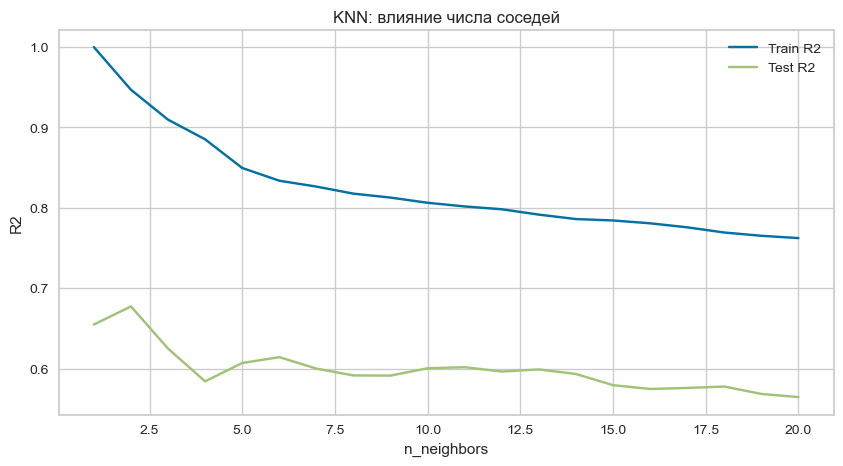

In [157]:
plt.figure(figsize=(10,5))
plt.plot(k_range, train_scores, label='Train R2')
plt.plot(k_range, test_scores, label='Test R2')
plt.xlabel('n_neighbors')
plt.ylabel('R2')
plt.title('KNN: влияние числа соседей')
plt.legend()
plt.grid(True)
plt.show()

In [163]:
knn_opt = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors = 4)).fit(X_train, y_train)
print(f'KNN training: {knn_opt.score(X_train, y_train)}')
print(f'KNN test: {knn_opt.score(X_test, y_test)}')

KNN training: 0.8852309086019282
KNN test: 0.5841289550541646


##### Decision Tree (решающее дерево)

In [166]:
depth_range = np.arange(1, 16)
train_scores, test_scores = [], []

In [194]:
for d in depth_range:
    model = DecisionTreeRegressor(max_depth=d, random_state=0)
    model.fit(X_train, y_train)
    
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

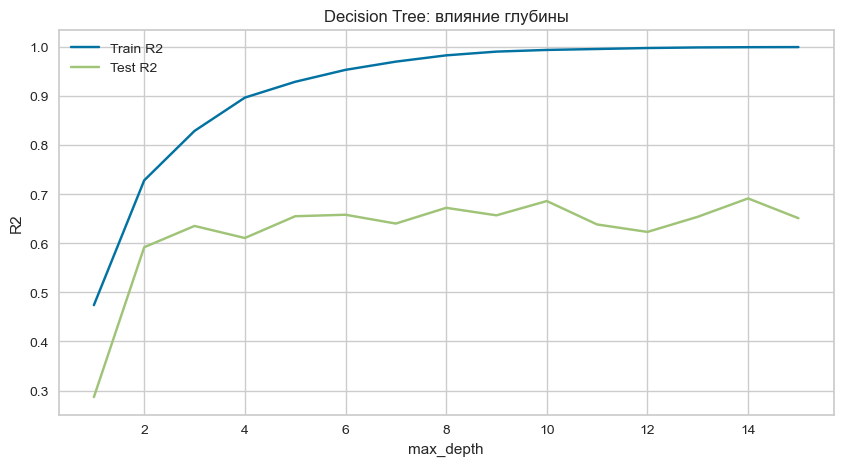

In [170]:
plt.figure(figsize=(10,5))
plt.plot(depth_range, train_scores, label='Train R2')
plt.plot(depth_range, test_scores, label='Test R2')
plt.xlabel('max_depth')
plt.ylabel('R2')
plt.title('Decision Tree: влияние глубины')
plt.legend()
plt.grid(True)
plt.show()

In [172]:
dt_opt = DecisionTreeRegressor(max_depth=4, random_state=0).fit(X_train, y_train)
print(f"Decision Tree Training: {dt_opt.score(X_train, y_train):.2f}")
print(f"Decision Tree Test: {dt_opt.score(X_test, y_test):.2f}")

Decision Tree Training: 0.90
Decision Tree Test: 0.61


#### 3. Дополните анализ датасета Бостон исследованием модели лассо - постройте кривые обучения для переобученной, недообученной и качественной модели, найдите оптимальное значение параметра регуляризации в модели лассо.

In [202]:
dataset = fetch_openml(data_id=531, as_frame=True, parser='auto')
#dataset = genfromtxt('https://raw.githubusercontent.com/datatweets/tutorials/refs/heads/main/misc/boston_housing.csv', delimiter=',')

In [204]:
X = dataset.data.values.astype(float)
y = dataset.target.values.astype(float)
#X = dataset[:,:-1]
#y = dataset[:,-1]

In [206]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

##### Кривая регуляризации (зависимость R2 от alpha):

In [209]:
alphas = np.logspace(-4, 2, 50)
train_scores, test_scores = [], []

In [211]:
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=100000) 
    lasso.fit(X_train, y_train)
    
    train_scores.append(lasso.score(X_train, y_train))
    test_scores.append(lasso.score(X_test, y_test))

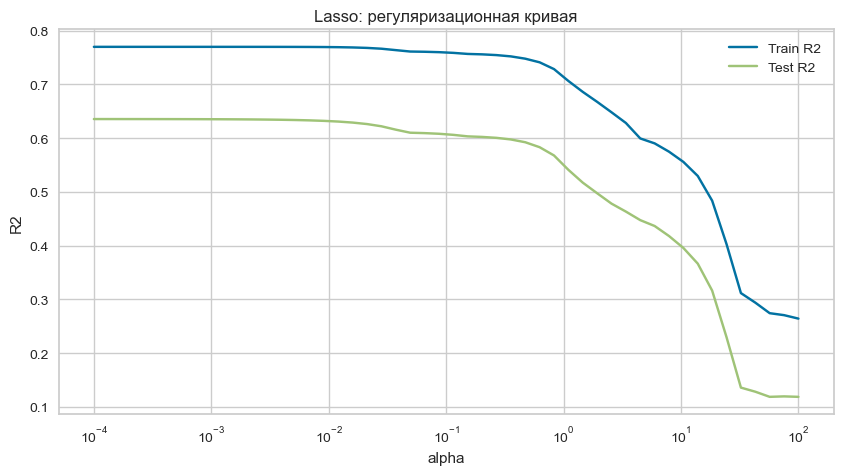

In [213]:
plt.figure(figsize=(10,5))
plt.semilogx(alphas, train_scores, label='Train R2')
plt.semilogx(alphas, test_scores, label='Test R2')
plt.xlabel('alpha')
plt.ylabel('R2')
plt.title('Lasso: регуляризационная кривая')
plt.legend()
plt.grid(True)
plt.show()

##### Кривые обучения для трёх характерных значений alpha:

- Недообучение (alpha слишком большая, например 1.0)
- Оптимальная (alpha в районе максимума, например 0.01)
- Переобучение (alpha слишком маленькая, например 0.0001)

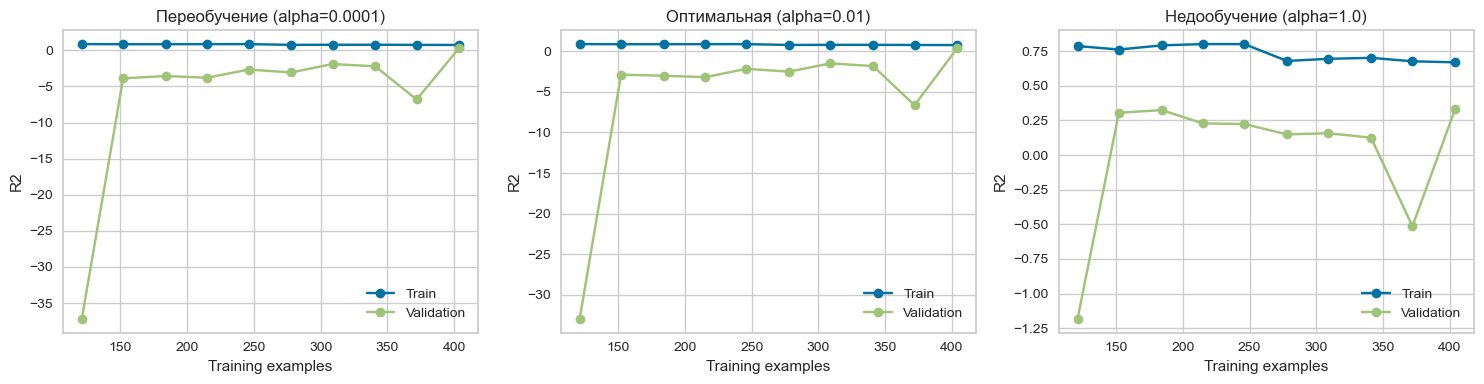

In [220]:
alphas_to_plot = [0.0001, 0.01, 1.0]
titles = ['Переобучение (alpha=0.0001)', 'Оптимальная (alpha=0.01)', 'Недообучение (alpha=1.0)']

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, a, title in zip(axes, alphas_to_plot, titles):
    pipe = make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=100000))
    train_sizes, train_scores, test_scores = learning_curve(
        pipe, X, y, train_sizes=np.linspace(0.3, 1.0, 10), cv=5,
        scoring='r2', n_jobs=-1)
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    ax.plot(train_sizes, train_mean, 'o-', label='Train')
    ax.plot(train_sizes, test_mean, 'o-', label='Validation')
    ax.set_xlabel('Training examples')
    ax.set_ylabel('R2')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

#### 4. В одном из двух первых примеров используйте модель ElasticNet и исследуйте влияние сразу двух параметров регуляризации на эффективность модели.

In [225]:
alphas = np.logspace(-4, 1, 50)
l1_ratios = [0.1, 0.5, 0.9]  # 0.1 – ближе к Ridge, 0.9 – ближе к Lasso

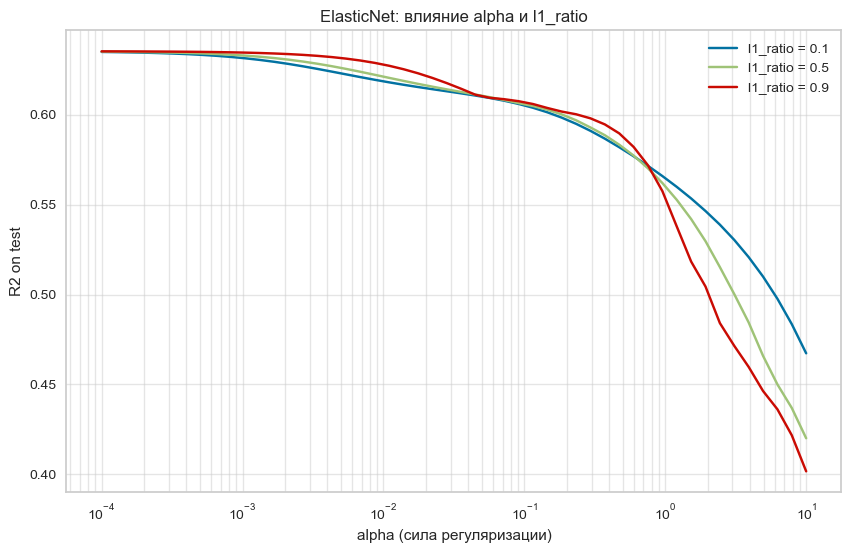

In [231]:
plt.figure(figsize=(10, 6))

for ratio in l1_ratios:
    test_scores = []
    for a in alphas:
        en = ElasticNet(alpha=a, l1_ratio=ratio, max_iter=100000)
        en.fit(X_train, y_train)
        
        test_scores.append(en.score(X_test, y_test))
    
    plt.semilogx(alphas, test_scores, label=f'l1_ratio = {ratio}')

plt.xlabel('alpha (сила регуляризации)')
plt.ylabel('R2 on test')
plt.title('ElasticNet: влияние alpha и l1_ratio')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

#### 5. Дополните анализ дерева решений из третьего примера: постройте кривые регуляризации для полного датасета, найдите оптимальную глубину дерева и оцените качество такой модели на всем датасете. Повторите данный анализ используя в качестве метрики эффективности F1.

##### Регрессия (R2)

In [234]:
depths = np.arange(1, 11)
train_scores, test_scores = validation_curve(
    DecisionTreeRegressor(random_state=0), X, y,
    param_name="max_depth", param_range=depths,
    cv=5, scoring="r2")

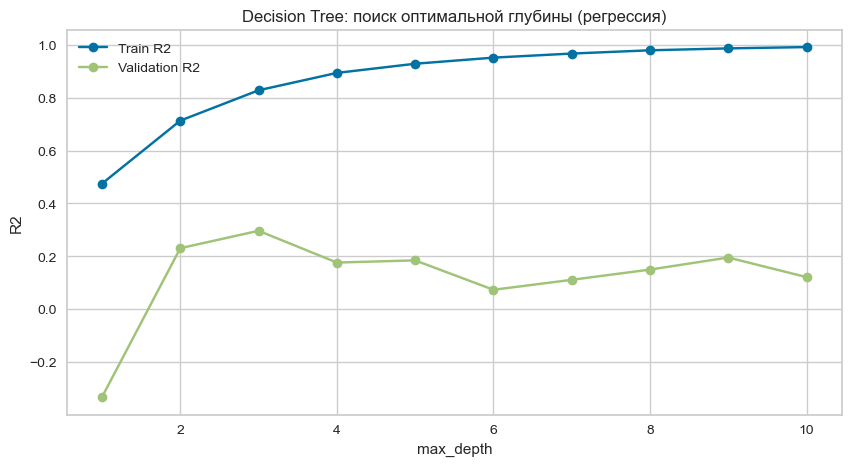

In [236]:
plt.figure(figsize=(10,5))
plt.plot(depths, np.mean(train_scores, axis=1), 'o-', label='Train R2')
plt.plot(depths, np.mean(test_scores, axis=1), 'o-', label='Validation R2')
plt.xlabel('max_depth')
plt.ylabel('R2')
plt.title('Decision Tree: поиск оптимальной глубины (регрессия)')
plt.legend()
plt.grid(True)
plt.show()

In [242]:
best_depth_r2 = depths[np.argmax(np.mean(test_scores, axis=1))]
print(f"Оптимальная глубина для регрессии: {best_depth_r2}")

Оптимальная глубина для регрессии: 3


In [244]:
final_tree_reg = DecisionTreeRegressor(max_depth=best_depth_r2, random_state=0)
final_tree_reg.fit(X, y)
print(f"Качество на всём датасете (R2): {final_tree_reg.score(X, y):.2f}")

Качество на всём датасете (R2): 0.82


##### Классификация (F1)

In [248]:
y_class = (y > np.median(y)).astype(int)

In [250]:
train_scores_f1, test_scores_f1 = validation_curve(
    DecisionTreeClassifier(random_state=0), X, y_class,
    param_name="max_depth", param_range=depths,
    cv=5, scoring="f1")

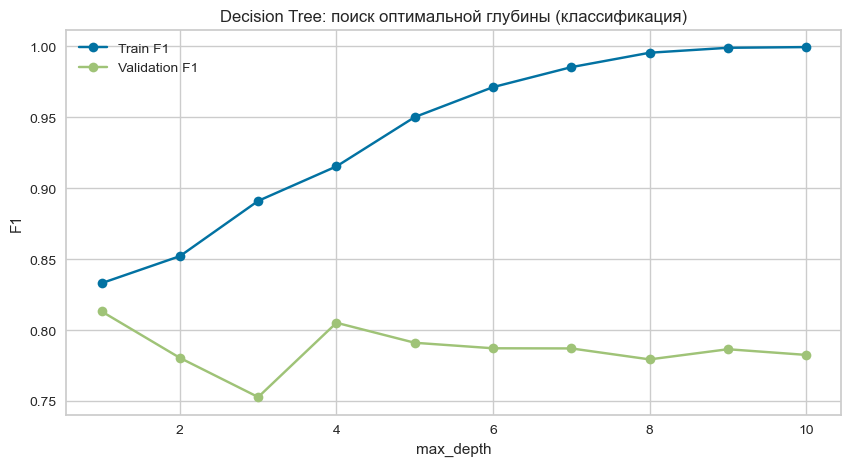

In [252]:
plt.figure(figsize=(10,5))
plt.plot(depths, np.mean(train_scores_f1, axis=1), 'o-', label='Train F1')
plt.plot(depths, np.mean(test_scores_f1, axis=1), 'o-', label='Validation F1')
plt.xlabel('max_depth')
plt.ylabel('F1')
plt.title('Decision Tree: поиск оптимальной глубины (классификация)')
plt.legend()
plt.grid(True)
plt.show()

In [254]:
best_depth_f1 = depths[np.argmax(np.mean(test_scores_f1, axis=1))]
print(f"Оптимальная глубина для классификации: {best_depth_f1}")

Оптимальная глубина для классификации: 1


In [256]:
final_tree_clf = DecisionTreeClassifier(max_depth=best_depth_f1, random_state=0)
final_tree_clf.fit(X, y_class)
y_pred_all = final_tree_clf.predict(X)
print(f"Качество на всём датасете (F1): {f1_score(y_class, y_pred_all):.2f}")

Качество на всём датасете (F1): 0.84


#### 6. Повторите анализ на других реальных датасетах из репозитория OpenML

- phoneme
- banknote-authentication
- delta_ailerons 
- mammography
- electricity
- mozilla4
- kropt
- nursery
- volcanoes-b3

In [348]:
dataset_kropt = 'kropt'
data = fetch_openml(name=dataset_name, version='active', as_frame=True, parser='auto')
X = data.data
y = data.target

In [350]:
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

In [352]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

In [354]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [356]:
model = make_pipeline(StandardScaler(), RidgeClassifier(alpha=1.0))
model.fit(X_train, y_train)
print(f"RidgeClassifier accuracy: {model.score(X_test, y_test):.4f}")

RidgeClassifier accuracy: 0.2672


In [358]:
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, train_sizes=np.linspace(0.1, 1.0, 10), cv=5,
    scoring='accuracy', n_jobs=-1)

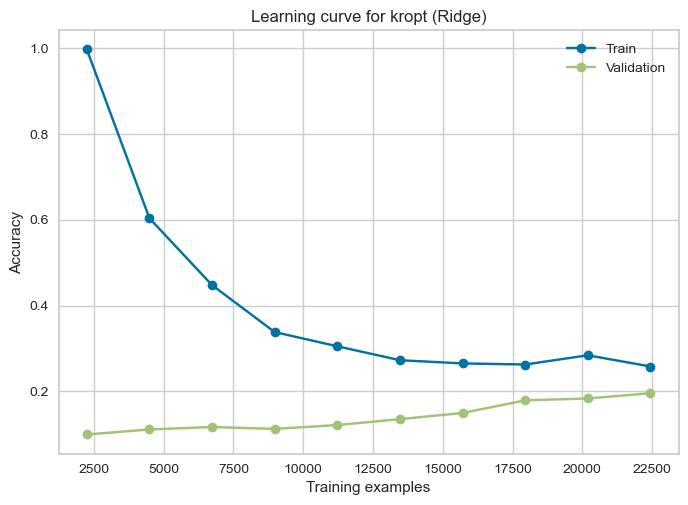

In [360]:
plt.figure()
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Train')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label='Validation')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.title(f'Learning curve for {dataset_name} (Ridge)')
plt.legend()
plt.grid(True)
plt.show()

In [362]:
alphas = np.logspace(-3, 5, 20)
train_acc, test_acc = [], []

In [364]:
for a in alphas:
    pipe = make_pipeline(StandardScaler(), RidgeClassifier(alpha=a))
    pipe.fit(X_train, y_train)
    
    train_acc.append(pipe.score(X_train, y_train))
    test_acc.append(pipe.score(X_test, y_test))

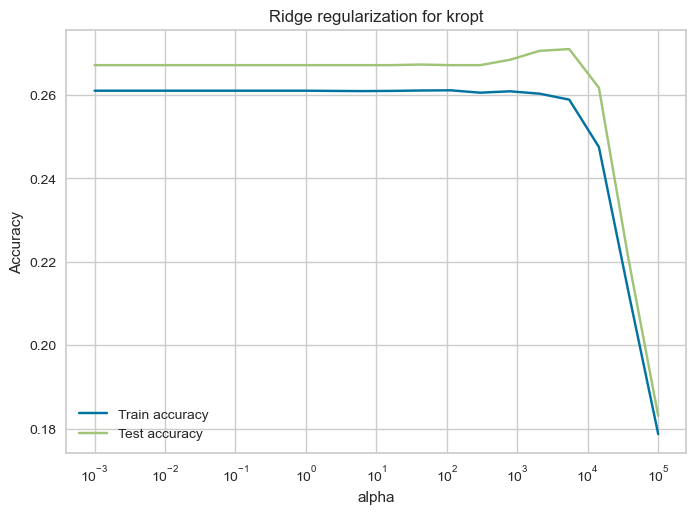

In [365]:
plt.figure()
plt.semilogx(alphas, train_acc, label='Train accuracy')
plt.semilogx(alphas, test_acc, label='Test accuracy')
plt.xlabel('alpha')
plt.ylabel('Accuracy')
plt.title(f'Ridge regularization for {dataset_name}')
plt.legend()
plt.grid(True)
plt.show()

In [370]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
print(f"RandomForest accuracy: {rf.score(X_test, y_test):.4f}")

RandomForest accuracy: 0.6463
